# EDA

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_pickle('/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/all_raw_samples.pkl')

In [4]:
data['outlier'].value_counts()

outlier
0    6914
1     343
Name: count, dtype: int64

### fixe outliers i plot

In [5]:
data['outliers_2'] = data['lipid_biomass_to_biomass'] / data['biomass_dilution']
data['outliers_2'] = data["outliers_2"].round(3)

deviating_rows = data[data["outliers_2"] != 0.134]

In [6]:
deviating_rows[deviating_rows['outlier'] != 1]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
1747,lcts_sample_562,0.116280,0.000664,0.004033,0.028808,0.000042,0.021830,0.184202,0.011365,0.000148,...,-2.608976,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.010116,-0.113082,0.414
1875,lcts_sample_690,0.208110,0.001476,0.008964,0.064032,0.000106,0.023205,0.189115,0.016515,0.000314,...,-5.789543,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.000733,-0.000693,0.293
1942,lcts_sample_757,0.273373,0.002012,0.012221,0.087299,0.000131,0.023212,0.097467,0.017527,0.000420,...,-7.677290,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.000686,-0.000417,0.142
2948,succ_sample_397,0.239297,0.001601,0.009722,0.069435,0.000117,0.023158,0.079270,0.015041,0.000507,...,0.000000,0.000000,-32.239791,0.000000,0.000000,succ,0,-0.000801,0.000234,0.135
4399,arg_glyc_sample_89,0.307538,0.002445,0.014845,0.106055,0.000174,0.023323,0.104025,0.019738,0.000489,...,0.000000,-17.781804,0.000000,-12.976655,0.000000,arg_glyc,0,-0.000657,0.000007,0.135
4881,arg_glyc_sample_571,0.303191,0.002385,0.014484,0.103474,0.000170,0.023294,0.102395,0.019429,0.000476,...,0.000000,-18.026341,0.000000,-14.656151,0.000000,arg_glyc,0,-0.000646,0.000007,0.135
5393,nh4_glc_sample_430,0.309589,0.002509,0.015231,0.108827,0.000148,0.023389,0.118177,0.020301,0.000748,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_glc,0,0.000039,-0.000714,0.149
5653,nh4_ac_sample_5,0.093756,0.000394,0.002394,0.017101,0.000014,0.013036,0.032101,0.005709,0.000138,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_ac,0,0.000020,-0.001273,0.144
5789,nh4_ac_sample_141,0.118656,0.000548,0.003332,0.023795,0.000028,0.016259,0.040820,0.007293,0.000240,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_ac,0,-0.001676,0.001122,0.143
5994,no3_glc_sample_55,0.078693,0.000312,0.001895,0.013542,0.000011,0.011042,0.028068,0.004798,0.000098,...,0.000000,0.000000,0.000000,0.000000,-1.967316,no3_glc,0,0.000016,-0.001288,0.150


In [7]:
mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.143)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1

In [8]:
data[data['outliers_2']>0.149]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
152,glc_sample_152,0.072573,0.000386,0.002345,0.016749,0.000032,0.020318,0.212064,0.009853,0.000077,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000994,-0.000434,0.550
269,glc_sample_269,0.079072,0.000452,0.002742,0.019580,0.000040,0.021780,0.250824,0.011302,0.000094,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000913,-0.000572,0.567
277,glc_sample_277,0.224226,0.001706,0.010356,0.073979,0.000125,0.023233,0.223305,0.018431,0.000363,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000693,-0.000901,0.310
285,glc_sample_285,0.165884,0.001075,0.006527,0.046624,0.000075,0.023060,0.189800,0.014201,0.000211,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000797,-0.000331,0.342
288,glc_sample_288,0.139277,0.000757,0.004595,0.032826,0.000038,0.020895,0.107061,0.010355,0.000153,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.010156,-0.057792,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7189,no3_glyc_sample_528,0.085363,0.000411,0.002498,0.017846,0.000020,0.017495,0.123762,0.007970,0.000112,...,0.0,-20.190327,0.0,0.0,-2.434921,no3_glyc,1,0.000025,-0.001146,0.397
7212,no3_glyc_sample_551,0.135686,0.000698,0.004240,0.030295,0.000030,0.019460,0.074433,0.009206,0.000184,...,0.0,-27.457635,0.0,0.0,-3.574892,no3_glyc,1,0.000030,-0.001102,0.207
7213,no3_glyc_sample_552,0.040402,0.000149,0.000904,0.006462,0.000005,0.008669,0.059640,0.003749,0.000049,...,0.0,-22.011385,0.0,0.0,-1.126556,no3_glyc,1,0.000012,-0.001327,0.407
7228,no3_glyc_sample_567,0.243341,0.001697,0.010304,0.073623,0.000087,0.023200,0.106264,0.016071,0.000506,...,0.0,-22.718702,0.0,0.0,-6.593583,no3_glyc,1,0.000050,-0.000827,0.169


In [9]:
data['outlier'].value_counts()

outlier
0    6909
1     348
Name: count, dtype: int64

## BM plot

In [10]:
bm_plot = data.iloc[:, 1:12]
bm_plot.columns = bm_plot.columns.str.split('_').str[0]
bm_plot = bm_plot.rename(columns={'dummy': 'dummy protein'})

In [11]:
bm_plot

reaction,protein,mRNA,tRNA,rRNA,ncRNA,DNA,lipid,constituent,prosthetic,peptidoglycan,dummy protein
0,0.042196,0.000141,0.000857,0.006121,2.441456e-06,0.005740,0.012988,0.002476,0.000023,0.002546,0.000704
1,0.159765,0.000848,0.005154,0.036808,4.305130e-05,0.020290,0.051581,0.009831,0.000187,0.010112,0.002666
2,0.087971,0.000360,0.002186,0.015621,1.398394e-05,0.012089,0.027658,0.005272,0.000099,0.005422,0.001468
3,0.056537,0.000202,0.001228,0.008771,5.394236e-06,0.007733,0.017523,0.003340,0.000051,0.003435,0.000943
4,0.011679,0.000033,0.000203,0.001449,1.736281e-07,0.001567,0.003545,0.000676,0.000009,0.000695,0.000195
...,...,...,...,...,...,...,...,...,...,...,...
7252,0.086283,0.000350,0.002127,0.015199,1.019906e-05,0.011859,0.027109,0.005167,0.000133,0.005315,0.001440
7253,0.026028,0.000080,0.000487,0.003478,8.774053e-07,0.003517,0.007955,0.001516,0.000043,0.001560,0.000434
7254,0.063490,0.000233,0.001414,0.010105,5.044354e-06,0.008709,0.019759,0.003766,0.000229,0.003874,0.001059
7255,0.065260,0.000241,0.001466,0.010478,5.212395e-06,0.008956,0.020325,0.003874,0.000216,0.003985,0.001089


In [12]:
ex_rxns = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

target_corr = bm_plot.copy()
target_corr[ex_rxns] = -data[ex_rxns]

## Distributions

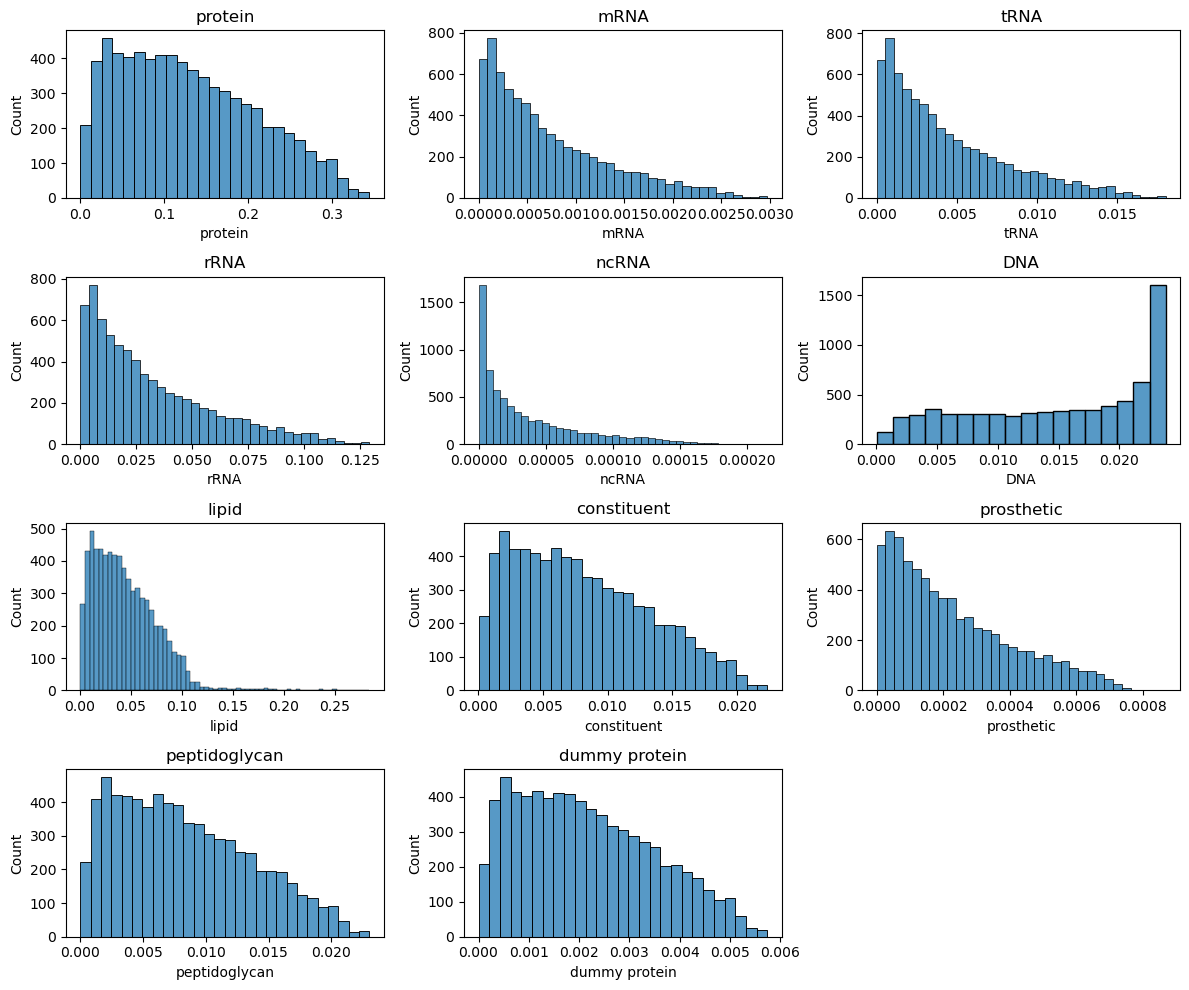

In [13]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, bm_plot.columns):
    sns.histplot(
        bm_plot[col],
        ax=ax,
    )
    ax.set_title(col)

# remove empty subplot (since 4x3 = 12 but you have 11 columns)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [14]:
nitrogen_sources = [
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

carbon_sources = ['glc', 'ac', 'lcts', 'glyc', 'succ']

bm_long = bm_plot.copy()
bm_long["source"] = data["source"].values

bm_long = bm_long.melt(
    id_vars="source",
    var_name="biomass_component",
    value_name="value"
)

bm_nitrogen = bm_long[bm_long["source"].isin(nitrogen_sources)]
bm_carbon = bm_long[bm_long["source"].isin(carbon_sources)]

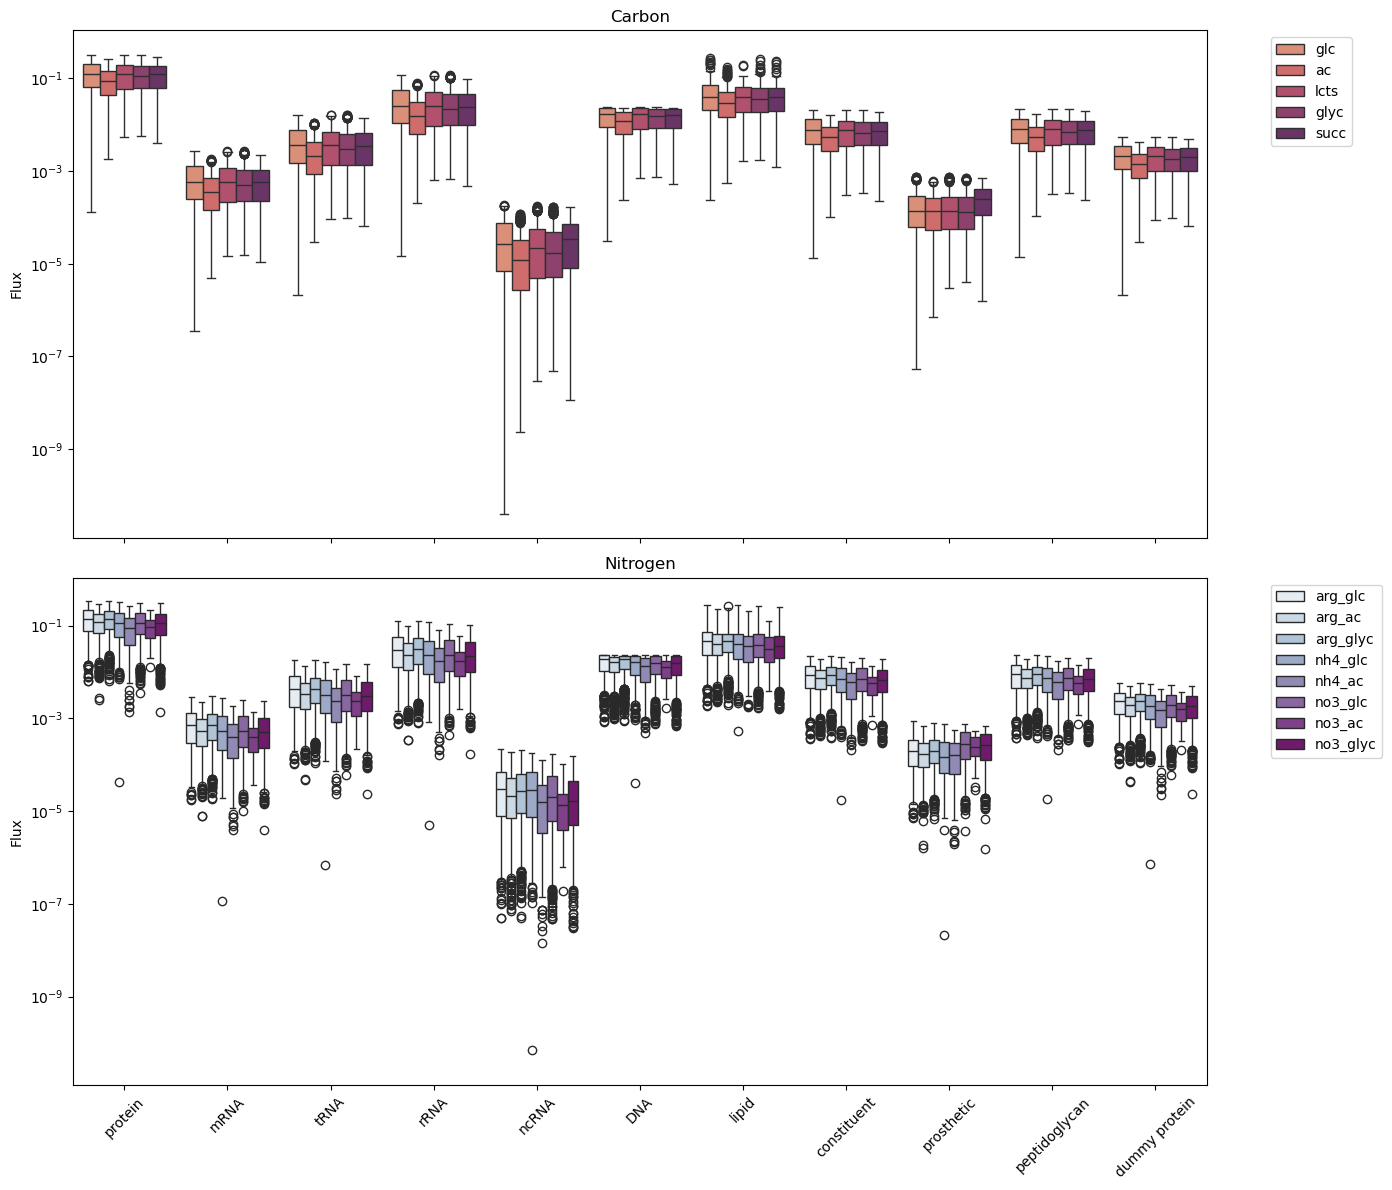

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)

sns.boxplot(
    data=bm_carbon,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[0],
    palette="flare"
)

axes[0].set_xlabel("")
axes[0].set_ylabel('Flux')
axes[0].set_yscale('log')
axes[0].set_title("Carbon")
axes[0].set_xticklabels([])
axes[0].set_yscale('log')
axes[0].legend(bbox_to_anchor=(1.05, 1))

sns.boxplot(
    data=bm_nitrogen,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[1],
    palette="BuPu"
)

axes[1].set_title("Nitrogen")
axes[1].set_ylabel('Flux')
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [16]:
color_map = sns.color_palette("crest", as_cmap=True)

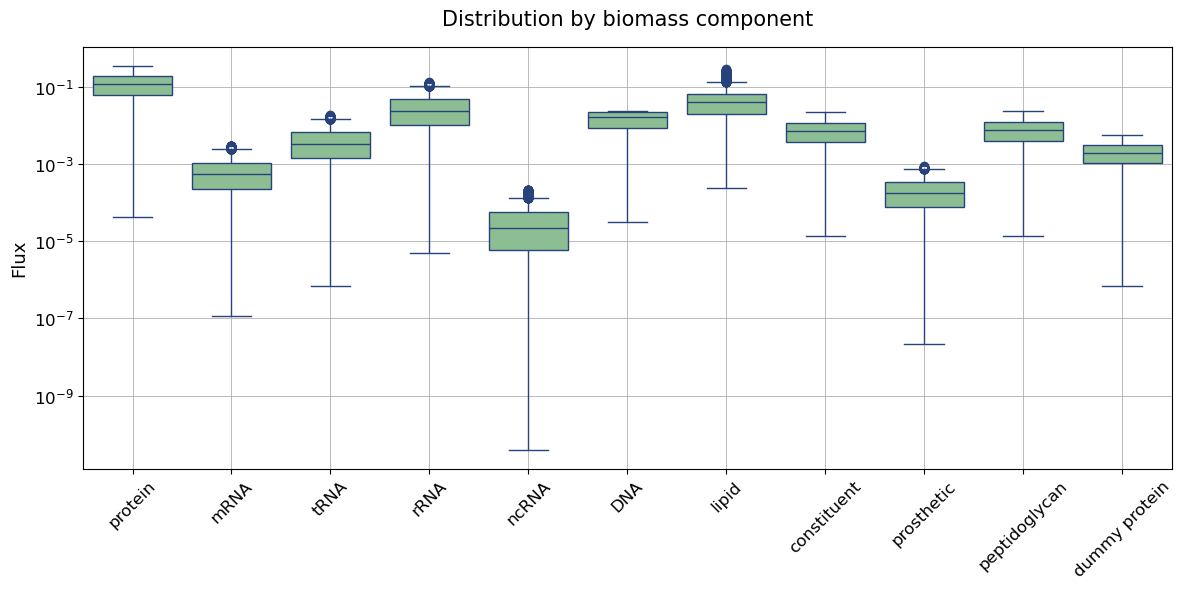

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(data=bm_plot, color=color_map(0.1), saturation=0.9, linecolor=color_map(0.9), linewidth=1.0)
plt.grid(True, linewidth=0.6)
plt.title("Distribution by biomass component", fontsize=15, pad=15)
plt.xlabel("")
plt.ylabel("Flux", fontsize=13)
plt.yscale("log")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Correlation

In [18]:
corr = target_corr.corr(method='spearman')

In [19]:
corr_annot = corr.iloc[:, 11:]
corr_annot = corr_annot.iloc[:-9]

corr_annot = corr_annot.reset_index()

corr_latex = corr_annot.to_latex(index=False, float_format="%.2f", column_format="lccccccccc")

print(corr_latex)

\begin{tabular}{lccccccccc}
\toprule
reaction & EX_o2_e & EX_glc__D_e & EX_ac_e & EX_lcts_e & EX_glyc_e & EX_succ_e & EX_arg__L_e & EX_nh4_e & EX_no3_e \\
\midrule
protein & -0.51 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
mRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
tRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
rRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
ncRNA & -0.50 & 0.04 & -0.32 & -0.02 & -0.05 & 0.06 & 0.03 & 0.18 & -0.06 \\
DNA & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
lipid & -0.56 & -0.00 & -0.28 & -0.02 & -0.02 & -0.01 & 0.04 & 0.13 & -0.03 \\
constituent & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
prosthetic & -0.48 & 0.01 & -0.26 & -0.10 & 0.01 & 0.07 & 0.01 & 0.04 & 0.19 \\
peptidoglycan & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
dummy protein & -0.51 & 0.01 & -0.33 & 0.00 & -

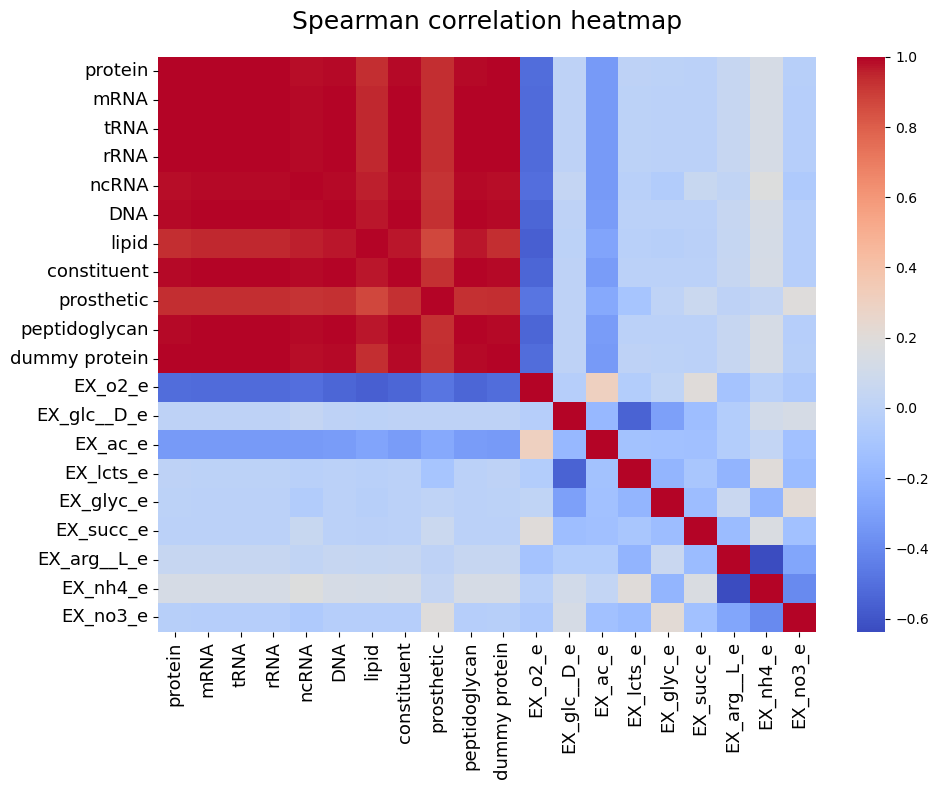

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap='coolwarm')

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, fontsize=13)
plt.yticks(fontsize=13)
plt.title('Spearman correlation heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## Component vs growth rate

In [21]:
color_map = sns.color_palette("GnBu", as_cmap=True)

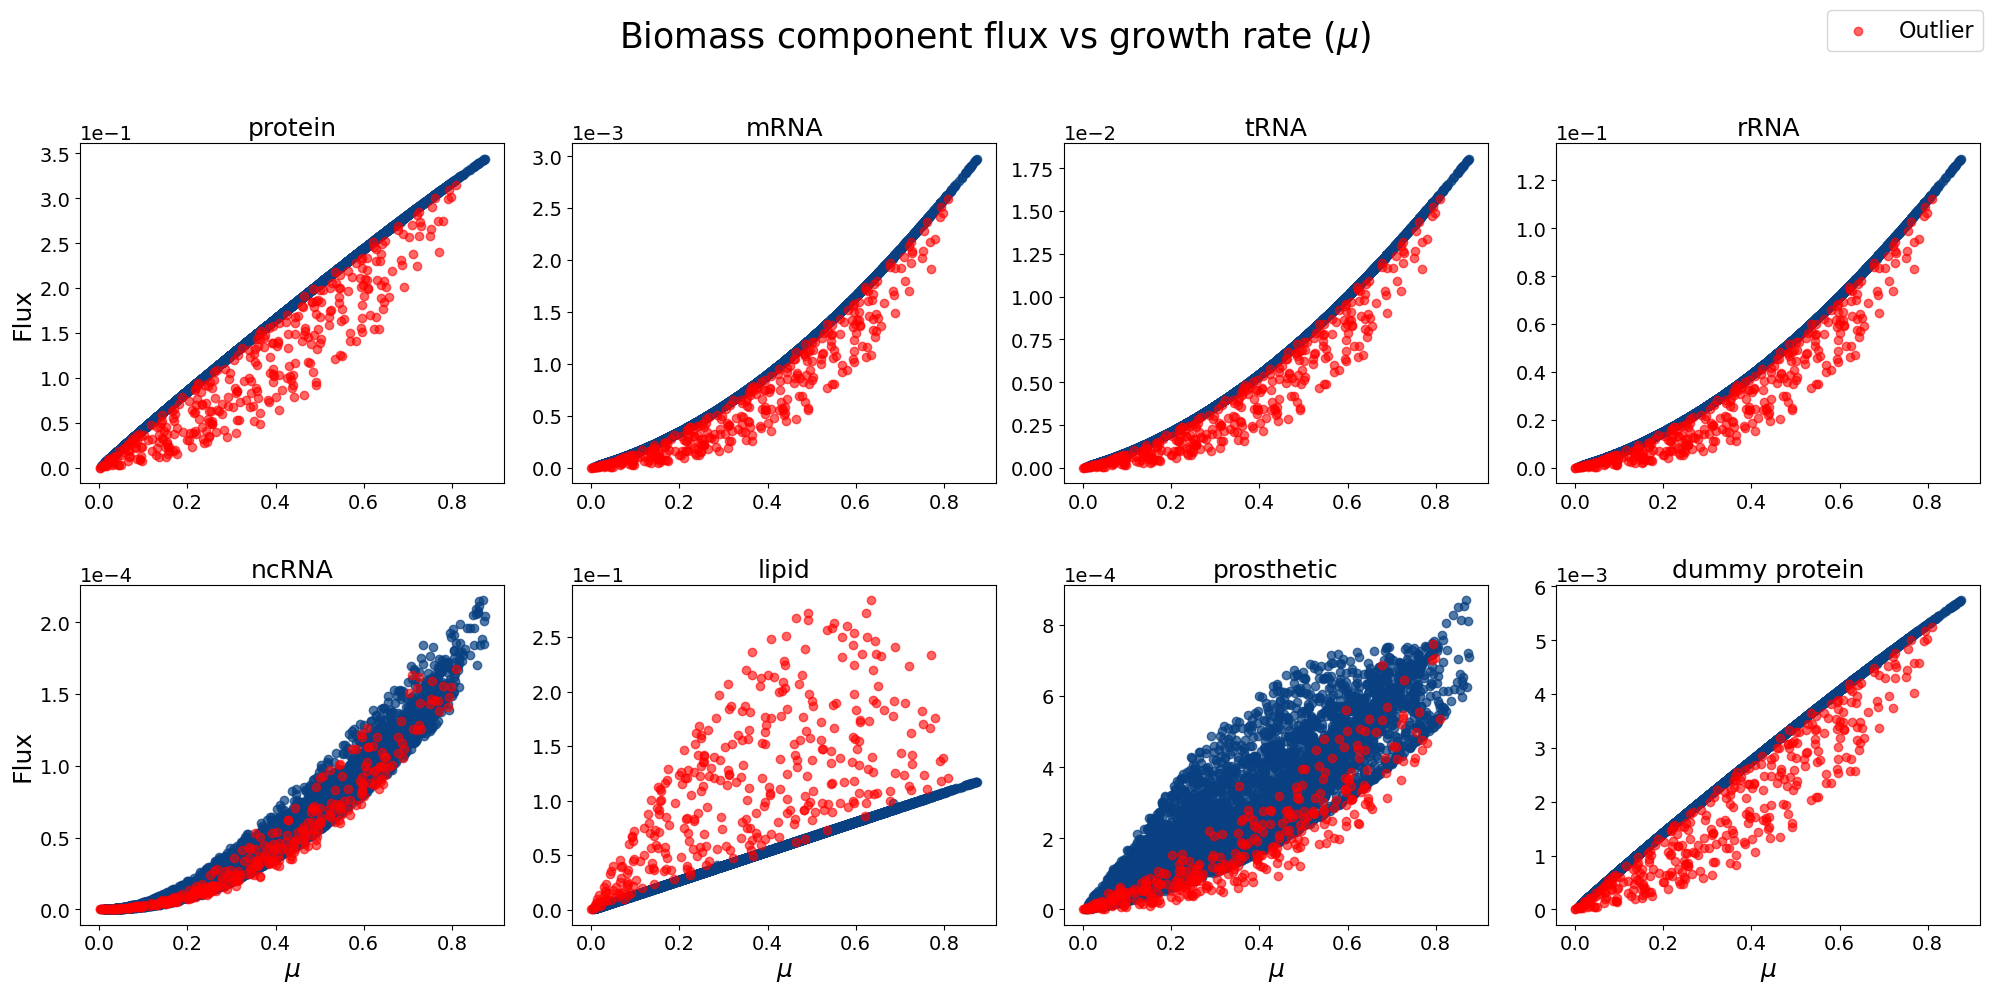

In [22]:
from matplotlib.ticker import ScalarFormatter

bm_plot_growth = bm_plot.copy()
bm_plot_growth = bm_plot_growth.drop(columns=['constituent', 'peptidoglycan', 'DNA'])
bm_plot_growth['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth.columns if col != x_col]

# Create mask (aligned with bm_plot_growth)
outlier_mask = data.loc[bm_plot_growth.index, 'outlier'] == 1

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    # Non-outliers (faint)
    axes[i].scatter(
        bm_plot_growth.loc[~outlier_mask, x_col],
        bm_plot_growth.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0)
    )
    
    # Outliers (highlighted)
    axes[i].scatter(
        bm_plot_growth.loc[outlier_mask, x_col],
        bm_plot_growth.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label='Outlier' if i == 0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')

    

axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("")
axes[3].set_xlabel("")

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

axes[4].set_ylabel("Flux", fontsize=18)
axes[5].set_ylabel("")
axes[6].set_ylabel("")
axes[7].set_ylabel("")


# Remove unused subplots
for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

fig.legend(loc='upper right', fontsize=16)

plt.suptitle(r"Biomass component flux vs growth rate ($\mu$)", fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

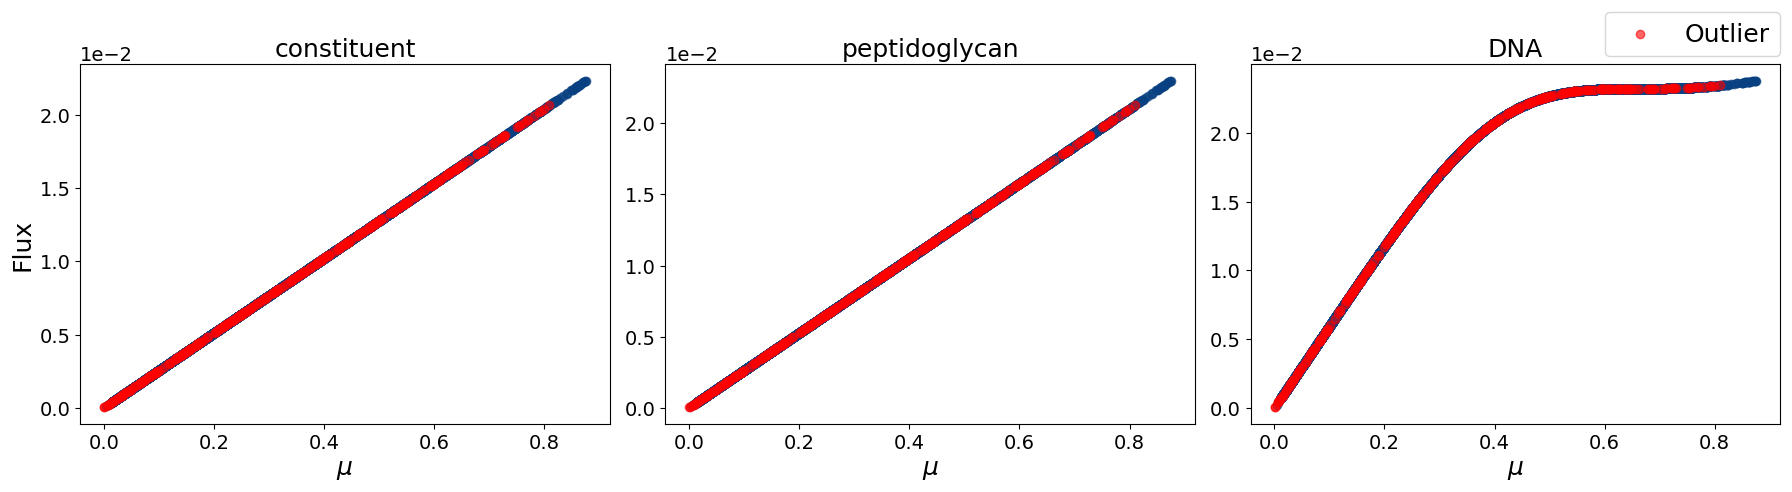

In [23]:
bm_plot_growth2 = bm_plot.copy()
bm_plot_growth2 = bm_plot_growth2[['constituent', 'peptidoglycan', 'DNA']]
bm_plot_growth2['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth2.columns if col != x_col]

# Create mask (aligned with bm_plot_growth)
outlier_mask = data.loc[bm_plot_growth2.index, 'outlier'] == 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    # Non-outliers (faint)
    axes[i].scatter(
        bm_plot_growth2.loc[~outlier_mask, x_col],
        bm_plot_growth2.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0)
    )
    
    # Outliers (highlighted)
    axes[i].scatter(
        bm_plot_growth2.loc[outlier_mask, x_col],
        bm_plot_growth2.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label='Outlier' if i==0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')
    

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# axes[1].set_yticklabels([])
# axes[2].set_yticklabels([])

# Remove unused subplots
for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

fig.legend(loc='upper right', fontsize=18)
# plt.suptitle(r"Biomass component flux vs growth rate ($\mu$)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## PCA

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
color_map = sns.color_palette("crest", as_cmap=True)

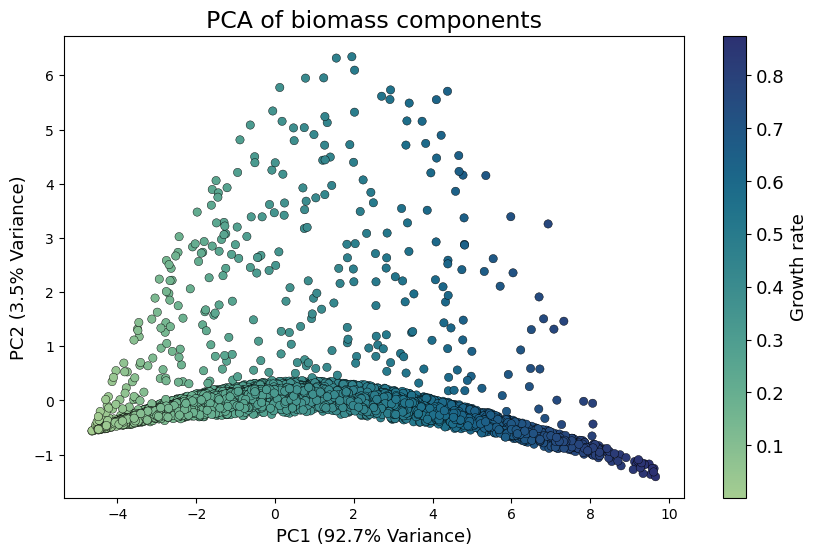

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bm_plot)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)
variance =  pca.explained_variance_ratio_


pca_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "biomass_dilution": data["biomass_dilution"].values
})

plt.figure(figsize=(10, 6))
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)

cbar = plt.colorbar(sc)
cbar.set_label(label=r"Growth rate", fontsize=13)
cbar.ax.tick_params(labelsize=13)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=13)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=13)

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

plt.title('PCA of biomass components', fontsize=17)
plt.show()

In [27]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    index=bm_plot.columns,
    columns=["PC1", "PC2"]
)


loadings = loadings.sort_values(by='PC1', ascending=False)
loadings = loadings.reset_index()
# loadings = loadings.reset_index().rename(columns={'index': 'Reaction'})

latex_loadings = loadings.to_latex(index=False, float_format="%.2f", column_format="lcc")
print(latex_loadings)

\begin{tabular}{lcc}
\toprule
reaction & PC1 & PC2 \\
\midrule
peptidoglycan & 0.31 & 0.07 \\
constituent & 0.31 & 0.07 \\
protein & 0.31 & -0.09 \\
dummy protein & 0.31 & -0.09 \\
tRNA & 0.31 & -0.18 \\
rRNA & 0.31 & -0.18 \\
mRNA & 0.31 & -0.18 \\
ncRNA & 0.30 & -0.16 \\
prosthetic & 0.29 & -0.25 \\
DNA & 0.29 & 0.31 \\
lipid & 0.26 & 0.83 \\
\bottomrule
\end{tabular}



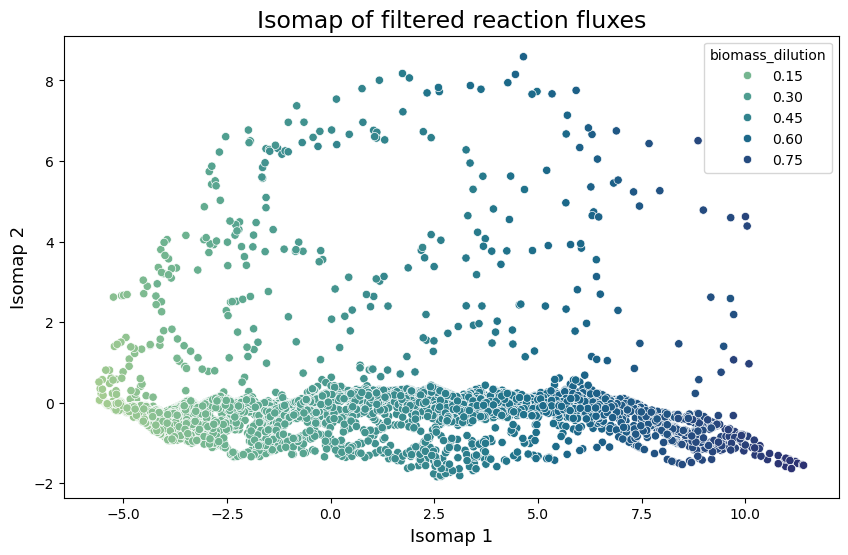

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bm_plot)

# Run Isomap
isomap = Isomap(
    n_components=2,     # usually visualize in 2D
    n_neighbors=5      # tune this
)

scores = isomap.fit_transform(X_scaled)

# Create dataframe
iso_df = pd.DataFrame({
    "ISO1": scores[:, 0],
    "ISO2": scores[:, 1],
    "biomass_dilution": data["biomass_dilution"].values,
    "source": data['source']
})

# Plot
plt.figure(figsize=(10, 6))

sc = sns.scatterplot(
    data=iso_df,
    x="ISO1",
    y="ISO2",
    hue="biomass_dilution",
    palette="crest",
    alpha=1.0
)

plt.xlabel("Isomap 1", fontsize=13)
plt.ylabel("Isomap 2", fontsize=13)

plt.title('Isomap of filtered reaction fluxes', fontsize=17)

plt.show()

# Biomass composition analysis - mass fractions

* plotte protein vs source uptake; vet at RNA/DNA er lineært, så holder med protein. Skal undersøke DNA også

In [29]:
bm_comp = bm_plot.copy()

bm_comp['RNA'] = bm_comp['ncRNA'] + bm_comp['rRNA'] + bm_comp['mRNA'] + bm_comp['tRNA']
bm_comp.drop(columns=['ncRNA', 'rRNA', 'mRNA', 'tRNA'], inplace=True)

# compute row totals
row_totals = bm_comp.sum(axis=1)
bm_frac = bm_comp.copy()
bm_frac = bm_frac.div(row_totals, axis=0)

bm_frac = bm_frac[['protein', 'DNA', 'RNA']]
bm_frac = bm_frac.rename(columns=lambda col: f"{col}_frac")

In [30]:
bm_comp[['protein_frac', 'DNA_frac', 'RNA_frac']] = bm_frac[['protein_frac', 'DNA_frac', 'RNA_frac']]
bm_comp['source'] = data['source']
bm_comp['outlier'] = data['outlier']
bm_comp[ex_rxns] = -data[ex_rxns]

In [31]:
color_map = sns.color_palette("crest", as_cmap=True)

In [32]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

carbon_plot = ['glc', 'ac', 'lcts', 'glyc', 'succ']
nitrogen_plot = ['arg_glc', 'arg_ac', 'arg_glyc', 'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

In [33]:
bm_comp['biomass_dilution'] = data['biomass_dilution']

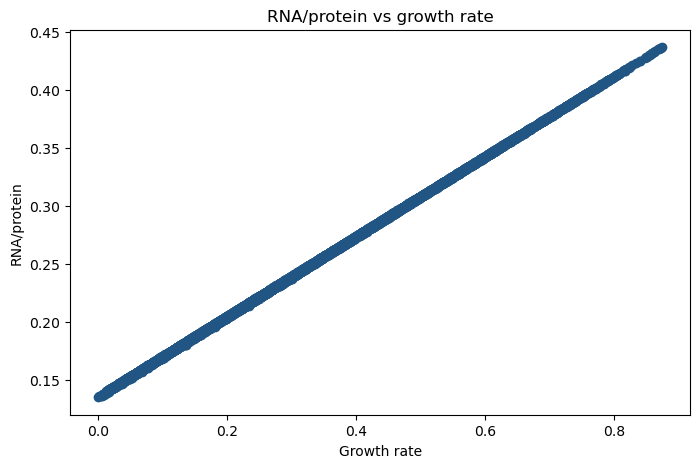

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(bm_comp['biomass_dilution'], bm_comp['RNA']/bm_comp['protein'], color=color_map(0.8))

plt.xlabel('Growth rate')
plt.ylabel('RNA/protein')

plt.title('RNA/protein vs growth rate')
plt.show()

In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import math


def plot_by_source_subplots(
    plot_df,
    y_col,
    source_col='source',
    source_to_xcol=None,
    sources_to_plot=None,
    dataset=None,
    color_col=None,
    cmap='viridis',
    ncols=4,
    figsize_per_col=(5, 4),
    point_alpha=0.6,
    non_outlier_size=36,
    outlier_col=None,
    outlier_size=80,
    outlier_marker='^',
    outlier_label='Outlier',
    y_label = None,
    colorbar_label= None
):
    """
    Plot one subplot per source value, where the x-variable is chosen from a
    mapped dataframe column based on the first token of the source name.
    Points are colored by a gradient based on a column of choice, with a single
    shared colorbar across all subplots.

    Outliers (if outlier_col is provided) are drawn on top of regular points
    with a distinct marker and larger size, but share the same color gradient.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing source column, y column, and x columns.
    y_col : str
        Column name to plot on the y-axis.
    source_col : str, default='source'
        Column containing source names like 'glc', 'arg_glc', etc.
    source_to_xcol : dict
        Mapping from source token -> dataframe x column.
        Example:
            {
                'glc': 'EX_glc__D_e',
                'ac': 'EX_ac_e',
                'arg': 'EX_arg__L_e',
                ...
            }
    sources_to_plot : list, optional
        Ordered list of full source labels to include as subplots.
        If None, all unique values in source_col are used.
    dataset : pd.DataFrame, optional
        DataFrame containing color_col and/or outlier_col, aligned by index.
        If None, plot_df is used.
    color_col : str, optional
        Column name used to determine the color gradient.
        If None, points are plotted with a single default color.
    cmap : str or Colormap, default='viridis'
        Colormap to use for the gradient.
    ncols : int, default=4
        Number of subplot columns.
    figsize_per_col : tuple, default=(5, 4)
        Width, height per subplot grid unit.
    point_alpha : float, default=0.6
        Alpha transparency for all scatter points.
    non_outlier_size : int, default=36
        Marker size for regular (non-outlier) points.
    outlier_col : str, optional
        Column (in dataset or plot_df) identifying outliers (1 = outlier).
        If None, no outlier distinction is made.
    outlier_size : int, default=80
        Marker size for outlier points.
    outlier_marker : str, default='^'
        Marker style for outlier points.
    outlier_label : str, default='Outlier'
        Legend label for outlier points.

    Returns
    -------
    fig, axes
    """
    if source_to_xcol is None:
        raise ValueError("source_to_xcol must be provided.")

    df = plot_df.copy()

    if sources_to_plot is not None:
        df = df[df[source_col].isin(sources_to_plot)].copy()
        sources_present = [s for s in sources_to_plot if s in df[source_col].unique()]
    else:
        sources_present = list(df[source_col].dropna().unique())

    if len(sources_present) == 0:
        raise ValueError("No matching sources found to plot.")

    # Use first token of source to determine x-column
    df['x_token'] = df[source_col].str.split('_').str[0]
    df['x_col'] = df['x_token'].map(source_to_xcol)

    # Drop rows where no x-column mapping exists
    df = df.dropna(subset=['x_col']).copy()

    # Extract x values row-wise
    df['x_val'] = [df.loc[idx, col_name] for idx, col_name in df['x_col'].items()]

    # Resolve color values and shared normalization
    if color_col is not None:
        color_source = dataset if (dataset is not None and color_col in dataset.columns) else df
        df['color_val'] = color_source.loc[df.index, color_col]

        vmin = df['color_val'].min()
        vmax = df['color_val'].max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
        scalar_mappable.set_array([])
    else:
        norm = None
        scalar_mappable = None

    # Resolve outlier mask
    if outlier_col is not None:
        outlier_source = dataset if (dataset is not None and outlier_col in dataset.columns) else df
        df['is_outlier'] = (outlier_source.loc[df.index, outlier_col] == 1)
    else:
        df['is_outlier'] = False

    n = len(sources_present)
    nrows = math.ceil(n / ncols)

    # Reserve horizontal space for the colorbar on the right
    colorbar_width_ratio = 0.08 if scalar_mappable is not None else 0
    fig = plt.figure(figsize=(figsize_per_col[0] * ncols, figsize_per_col[1] * nrows))

    # GridSpec: subplot columns + optional narrow colorbar column
    if scalar_mappable is not None:
        gs = gridspec.GridSpec(
            nrows, ncols + 1,
            width_ratios=[1] * ncols + [colorbar_width_ratio],
            figure=fig
        )
        cbar_ax = fig.add_subplot(gs[:, ncols])
    else:
        gs = gridspec.GridSpec(nrows, ncols, figure=fig)
        cbar_ax = None

    axes = [fig.add_subplot(gs[i // ncols, i % ncols]) for i in range(n)]

    legend_handles = []

    for i, src in enumerate(sources_present):
        ax = axes[i]
        sub = df[df[source_col] == src]

        if sub.empty:
            ax.set_visible(False)
            continue

        normal = sub[~sub['is_outlier']]
        outliers = sub[sub['is_outlier']]

        # --- scatter kwargs shared between normal and outlier calls ---
        scatter_kw = dict(alpha=point_alpha)
        if scalar_mappable is not None:
            scatter_kw.update(cmap=cmap, norm=norm)

        def _scatter(ax, rows, marker='o', size=non_outlier_size, **extra):
            kw = {**scatter_kw, **extra}
            if scalar_mappable is not None:
                return ax.scatter(
                    rows['x_val'], rows[y_col],
                    c=rows['color_val'],
                    s=size, marker=marker, **kw
                )
            else:
                return ax.scatter(
                    rows['x_val'], rows[y_col],
                    color='steelblue',
                    s=size, marker=marker, **kw
                )

        # Draw non-outliers first (below), then outliers on top
        if not normal.empty:
            _scatter(ax, normal, marker='o', size=non_outlier_size, zorder=2)

        if not outliers.empty:
            sc = _scatter(ax, outliers, marker=outlier_marker, size=outlier_size, zorder=3)
            # Collect one legend handle from the first subplot that has outliers
            if i == next((j for j, s in enumerate(sources_present)
                          if not df[(df[source_col] == s) & df['is_outlier']].empty), None):
                import matplotlib.lines as mlines
                handle = mlines.Line2D(
                    [], [], color='grey', marker=outlier_marker,
                    linestyle='None', markersize=9, label=outlier_label
                )
                legend_handles.append(handle)

        ax.set_title(src, fontsize=15)
        ax.set_xlabel(sub['x_col'].iloc[0], fontsize=12)

        if y_label is None:
            ax.set_ylabel(y_col, fontsize=15)
        else:
            ax.set_ylabel(y_label, fontsize=15)

    # Hide any unused axes slots
    for k in range(n, nrows * ncols):
        dummy = fig.add_subplot(gs[k // ncols, k % ncols])
        dummy.set_visible(False)

    # Shared colorbar
    if scalar_mappable is not None and cbar_ax is not None:
        cbar = fig.colorbar(scalar_mappable, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=13)

        # cbar.set_ticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.55])
        if colorbar_label is None:
            cbar.set_label(color_col, fontsize=15, labelpad=20)
        else:
            cbar.set_label(colorbar_label, fontsize=15, labelpad=20)

    # Legend for outlier marker
    if legend_handles:
        fig.legend(handles=legend_handles, loc='upper right', fontsize=12)

    plt.tight_layout()
    return fig, axes

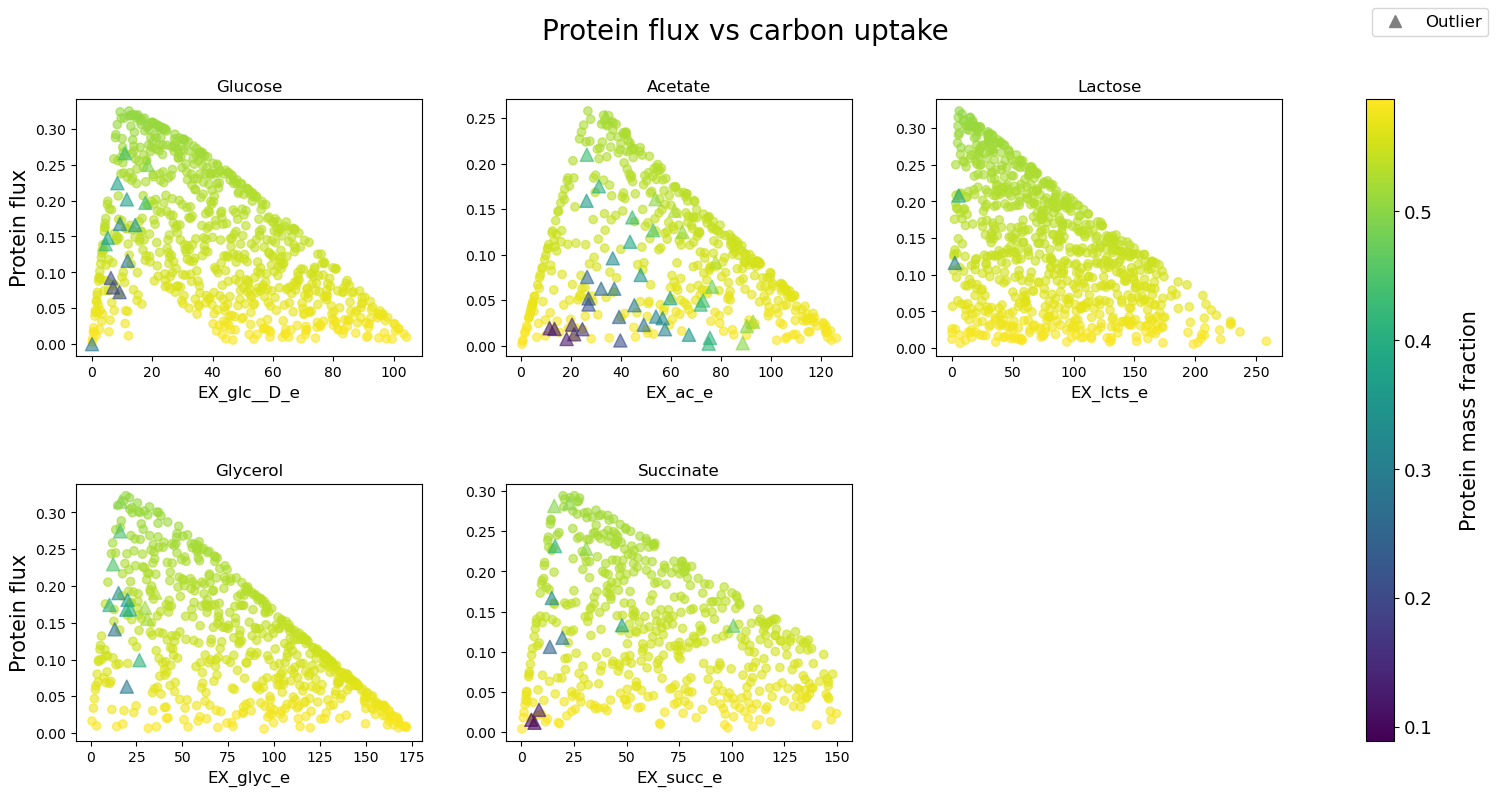

In [36]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('Protein flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

In [37]:
bm_plot['biomass_dilution'] = data['biomass_dilution']

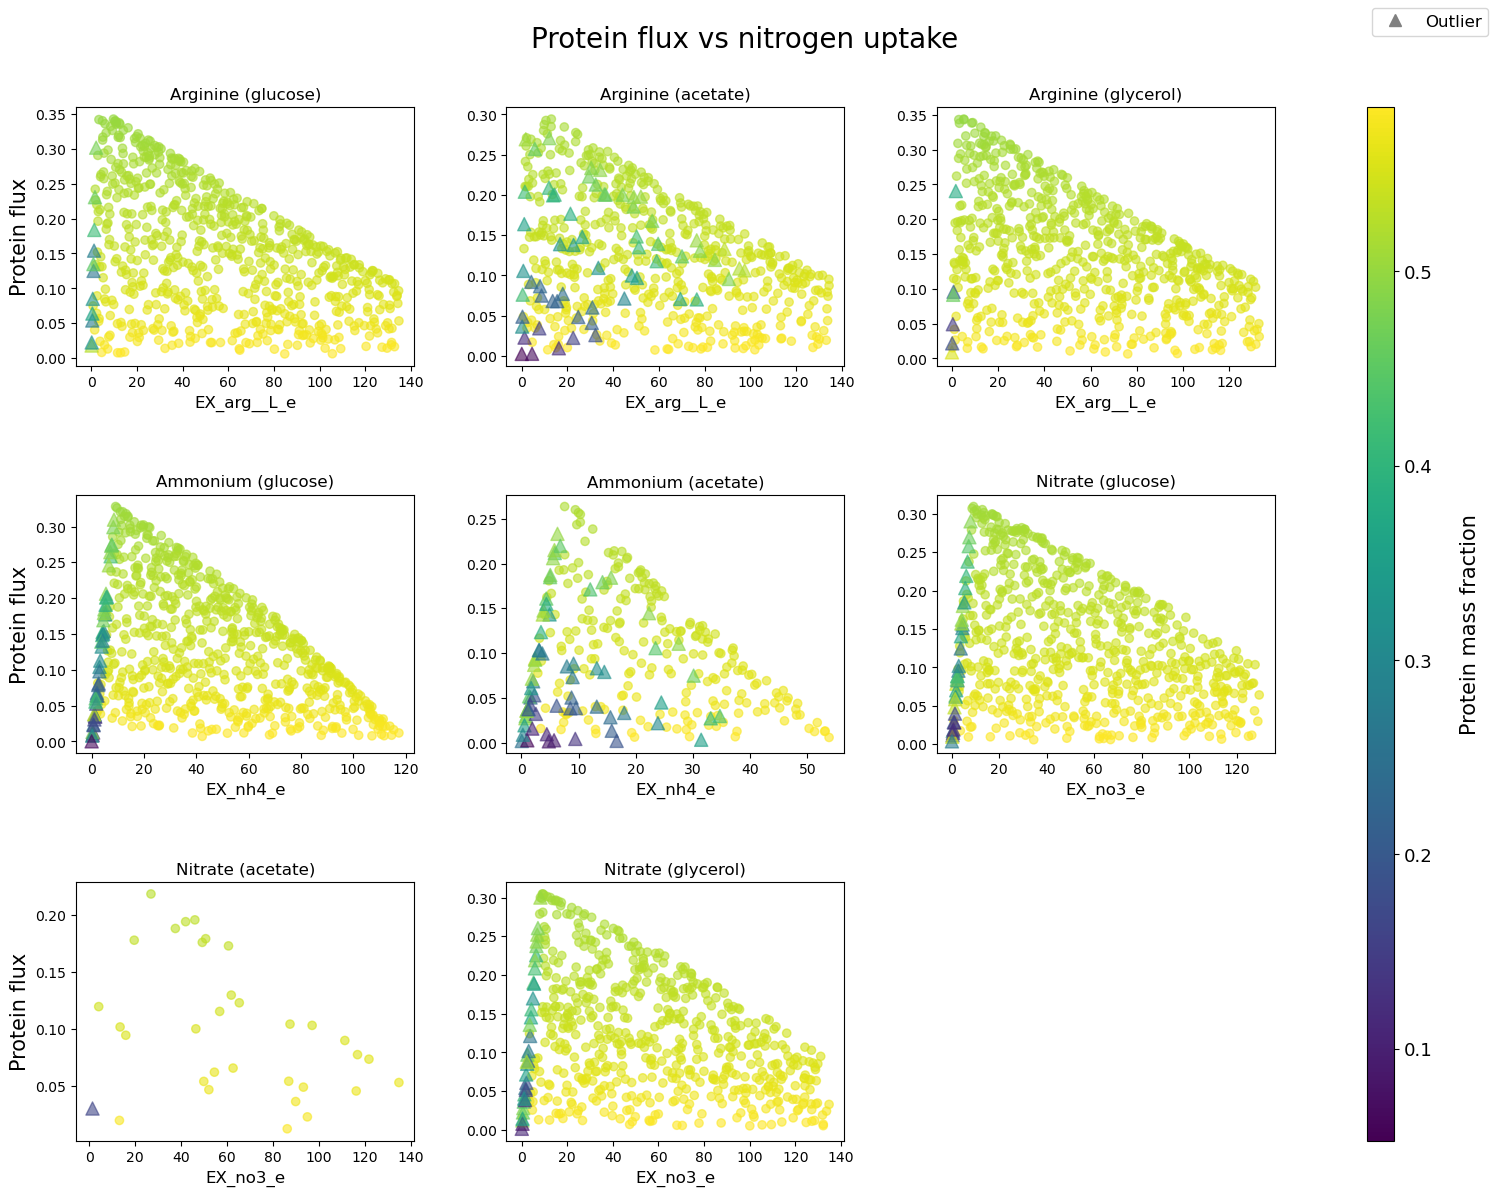

In [38]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction'  
)

plt.suptitle('Protein flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

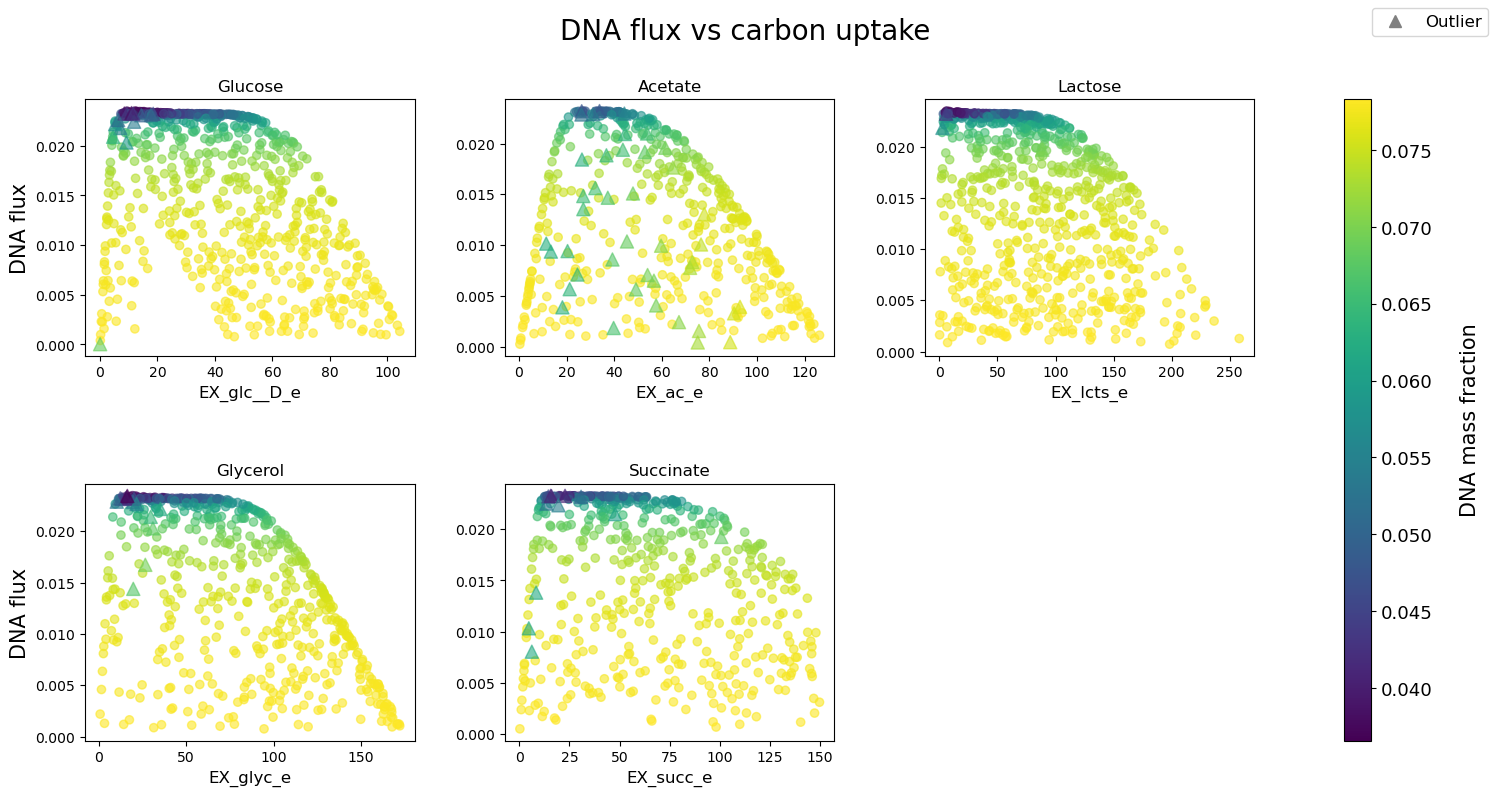

In [39]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA mass fraction'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('DNA flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

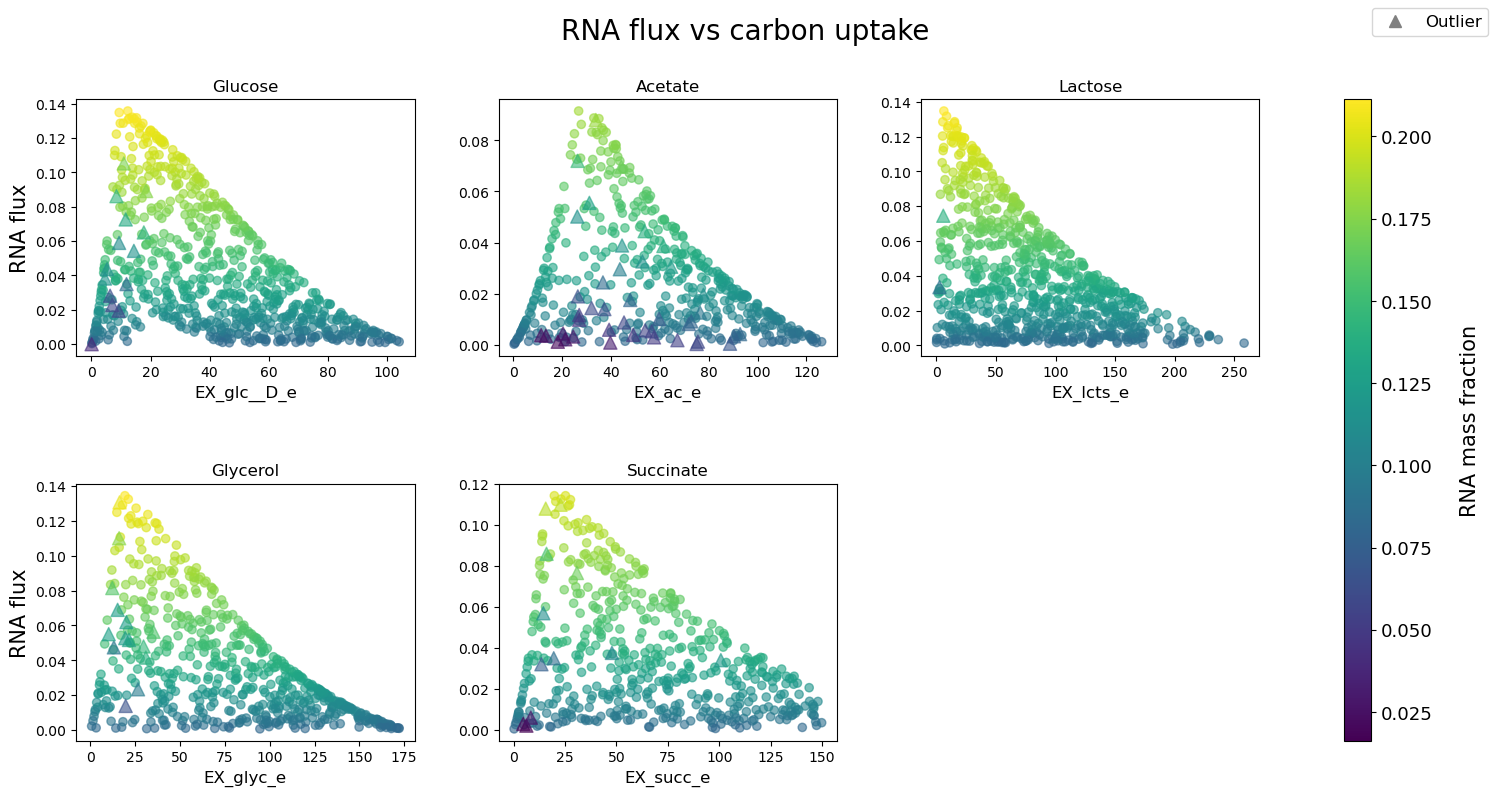

In [67]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA mass fraction'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('RNA flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

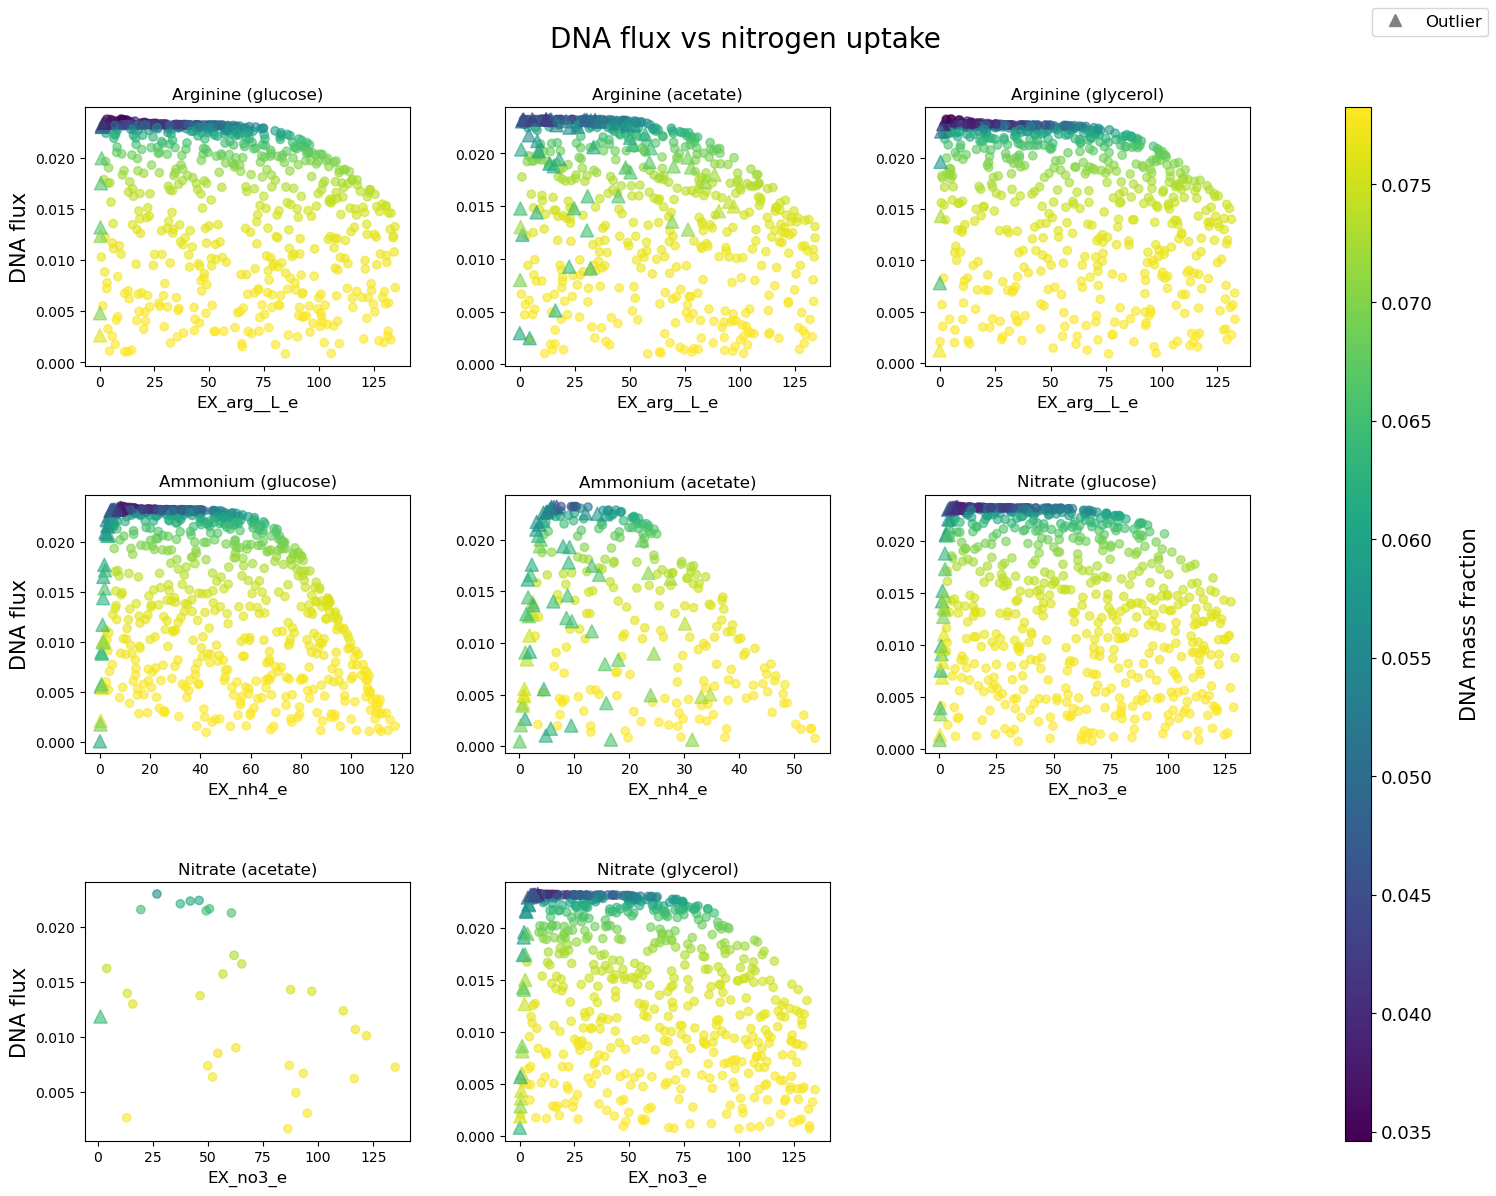

In [40]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA mass fraction'  
)

plt.suptitle('DNA flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

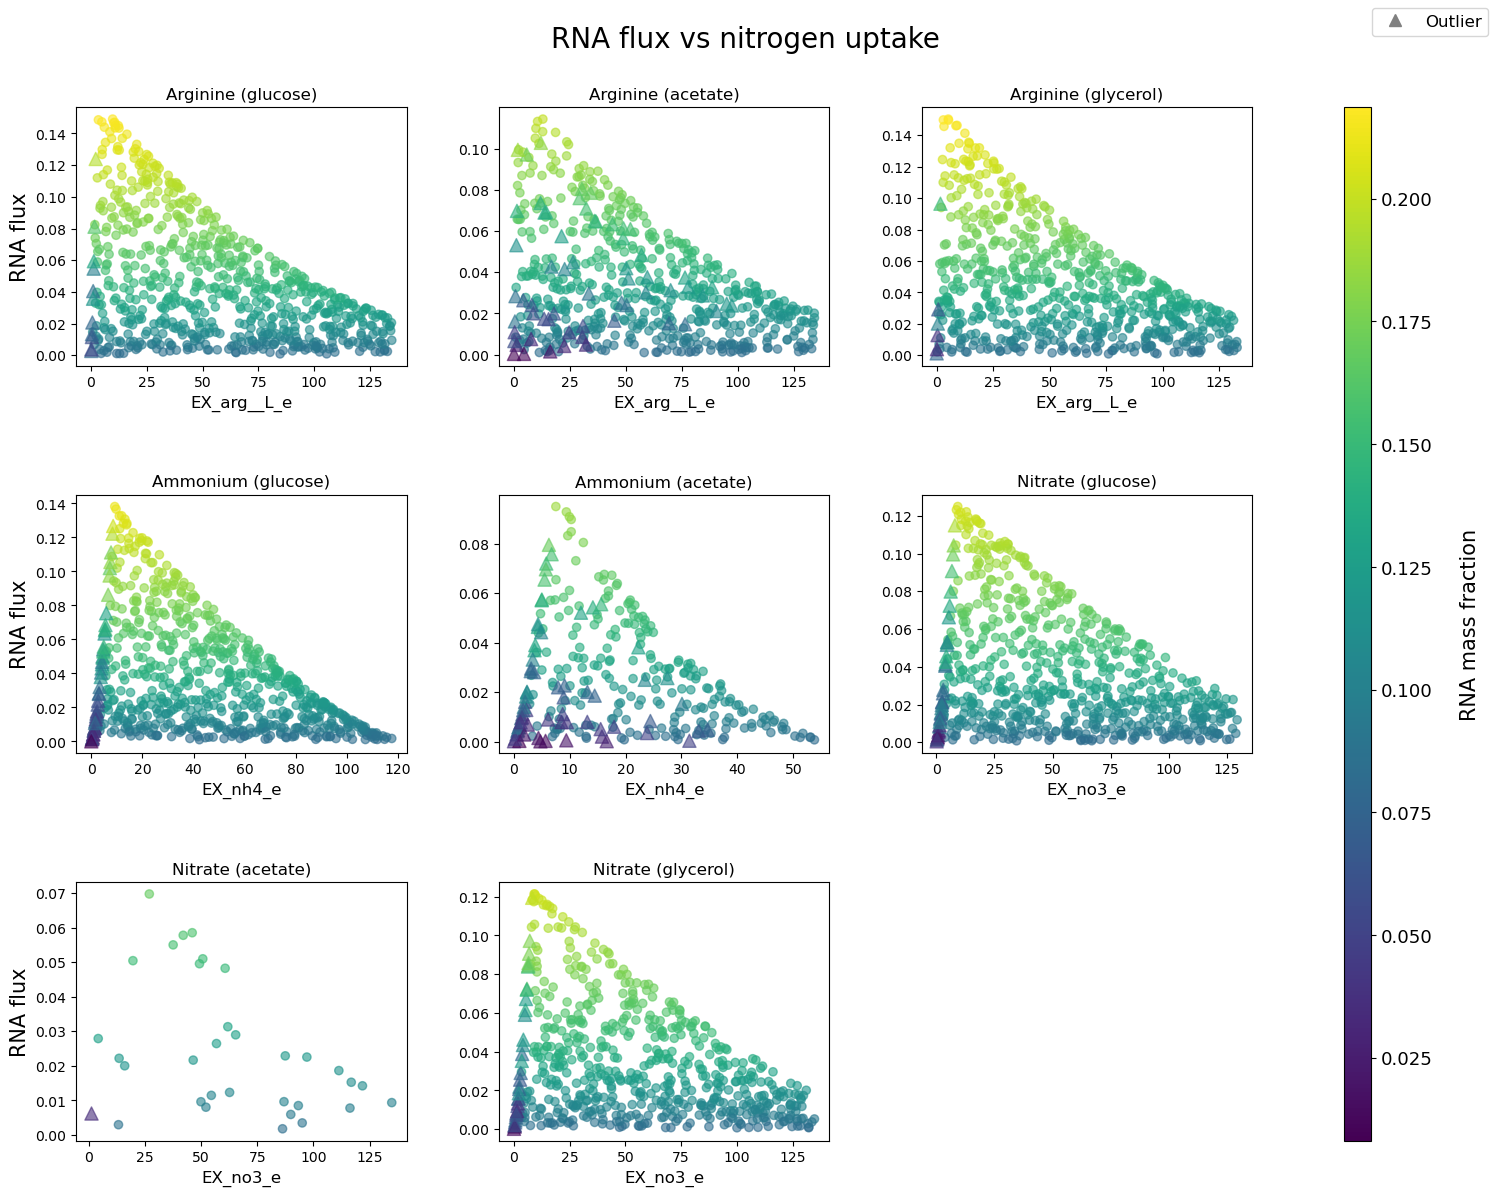

In [66]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA mass fraction'  
)

plt.suptitle('RNA flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

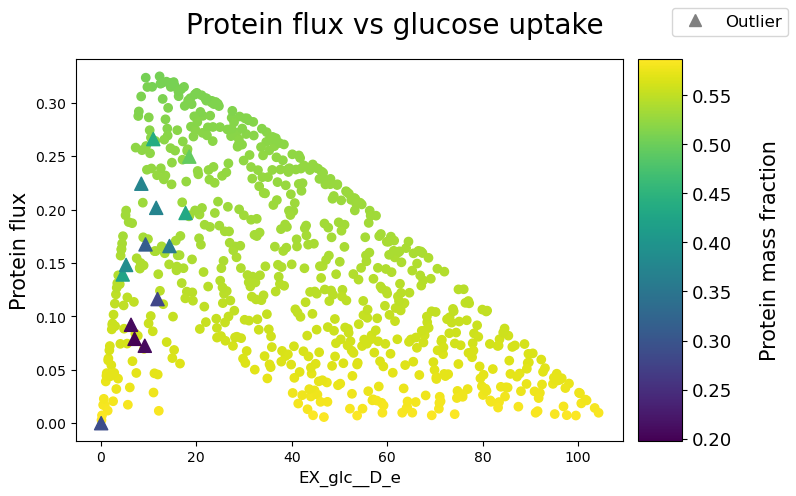

In [60]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction',
    point_alpha=1.0
)

axes[0].set_title("")

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('Protein flux vs glucose uptake', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

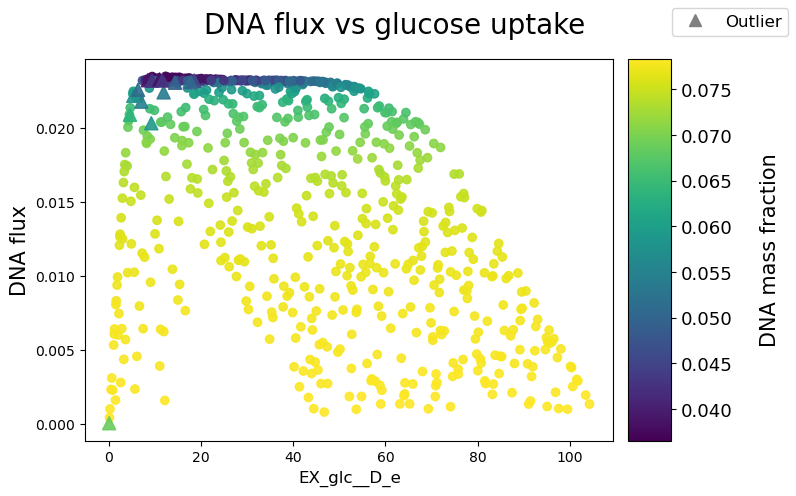

In [65]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA mass fraction',
    point_alpha=0.9,

)

axes[0].set_title("")

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('DNA flux vs glucose uptake', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

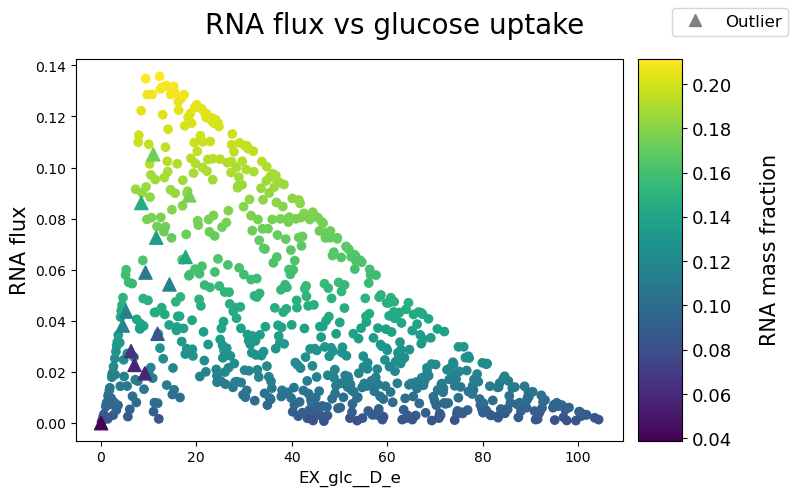

In [63]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA mass fraction',
    point_alpha=1.0
)

axes[0].set_title("")

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('RNA flux vs glucose uptake', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

# Shadow prices ? 

In [41]:
glc = data[data['source'] == 'glc']

In [42]:
glc[glc['outlier']==1]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
152,glc_sample_152,0.072573,3.862148e-04,0.002345,0.016749,3.164671e-05,0.020318,0.212064,0.009853,7.650367e-05,...,0.0,0.0,0.0,0.0,0.0,glc,1,-9.936895e-04,-0.000434,0.550
269,glc_sample_269,0.079072,4.515476e-04,0.002742,0.019580,3.967346e-05,0.021780,0.250824,0.011302,9.429584e-05,...,0.0,0.0,0.0,0.0,0.0,glc,1,-9.131616e-04,-0.000572,0.567
277,glc_sample_277,0.224226,1.705666e-03,0.010356,0.073979,1.246809e-04,0.023233,0.223305,0.018431,3.632803e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-6.929262e-04,-0.000901,0.310
285,glc_sample_285,0.165884,1.074762e-03,0.006527,0.046624,7.523574e-05,0.023060,0.189800,0.014201,2.105385e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.966844e-04,-0.000331,0.342
288,glc_sample_288,0.139277,7.569364e-04,0.004595,0.032826,3.757830e-05,0.020895,0.107061,0.010355,1.528638e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-1.015586e-02,-0.057792,0.264
334,glc_sample_334,0.000130,3.462005e-07,0.000002,0.000015,3.917916e-11,0.000031,0.000242,0.000013,5.455398e-08,...,0.0,0.0,0.0,0.0,0.0,glc,1,7.366932e-08,-0.000692,0.466
373,glc_sample_373,0.167419,1.166758e-03,0.007085,0.050606,9.089648e-05,0.023200,0.250350,0.016028,2.408359e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.500258e-04,-0.000401,0.399
415,glc_sample_415,0.249555,1.764351e-03,0.010716,0.076549,1.097723e-04,0.023205,0.106249,0.016420,3.418153e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.227430e-04,-0.000272,0.165
436,glc_sample_436,0.116249,6.926128e-04,0.004207,0.030042,5.149150e-05,0.022407,0.214856,0.012245,1.366245e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-8.627490e-04,-0.000384,0.449
563,glc_sample_563,0.265969,2.082383e-03,0.012644,0.090331,1.468237e-04,0.023280,0.169756,0.019262,4.244251e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-6.402248e-04,-0.000288,0.225


In [43]:
glc.sort_values(by='source_shadow', ascending=True)

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
556,glc_sample_556,0.120630,0.000556,0.003378,0.024110,0.000017,0.016306,0.038395,0.007318,0.000104,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000003,-0.066036,0.134
598,glc_sample_598,0.126872,0.000600,0.003641,0.026013,0.000021,0.017046,0.040498,0.007718,0.000114,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000003,-0.065650,0.134
328,glc_sample_328,0.131073,0.000629,0.003819,0.027283,0.000022,0.017522,0.041903,0.007985,0.000120,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000003,-0.065407,0.134
7,glc_sample_7,0.093423,0.000388,0.002359,0.016828,0.000009,0.012814,0.029409,0.005606,0.000070,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000003,-0.065029,0.134
167,glc_sample_167,0.092050,0.000381,0.002317,0.016539,0.000010,0.012634,0.028972,0.005522,0.000069,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000003,-0.064980,0.134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,glc_sample_354,0.248264,0.001702,0.010338,0.073846,0.000099,0.023189,0.081997,0.015628,0.000406,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000020,0.000065,0.134
509,glc_sample_509,0.250640,0.001729,0.010502,0.075014,0.000100,0.023194,0.082835,0.015788,0.000417,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000021,0.000065,0.134
211,glc_sample_211,0.282037,0.002106,0.012793,0.091379,0.000138,0.023218,0.094071,0.017930,0.000450,...,0.0,0.0,0.0,0.0,0.0,glc,0,-0.000013,0.000066,0.134
82,glc_sample_82,0.287674,0.002179,0.013233,0.094536,0.000129,0.023229,0.096149,0.018326,0.000590,...,0.0,0.0,0.0,0.0,0.0,glc,0,0.000045,0.000066,0.134
